In [1]:
#unhashtag this to install required libraries
%pip install pandas numpy matplotlib scikit-learn

import sys
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import ops
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision
from sklearn.preprocessing import StandardScaler
print(tf.__version__)



Note: you may need to restart the kernel to use updated packages.
2.16.2


In [9]:
#importing datasets
#at minimum include “Age”, “BMI”, and “Blood Glucose Level”

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

target = "HbA1c_level"

#Making y DataFrame for the model
y_train = train[target].astype("float32").values
y_test  = test[target].astype("float32").values


#Dropping columns that we don't need when making the x_train and x_test DataFrame
train = train.drop(columns=["Unnamed: 0","former", "current", "ever", "never","no info", "not current", target, "male", "female", "other"])
test = test.drop(columns=["Unnamed: 0","former", "current", "ever", "never", "no info", "not current", target, "male", "female", "other"])


#Scaling continuous variables for easier use in model
#Binary columns are already created via preprocessing.
def separate_cols(x):
    bin_col = pd.DataFrame()
    cont_col = pd.DataFrame()
    for col in x.columns:
        if x[col].nunique() == 2:
            bin_col[col] = x[col].values
        else:
            cont_col[col] = x[col].values
    return bin_col, cont_col

train_bin, train_cont = separate_cols(train)
test_bin, test_cont = separate_cols(test)

#Scaling
scaled = sc.fit_transform(train_cont)
scaled_te = sc.transform(test_cont)
#making dataframes for scaled sets
scaled_tr_cont = pd.DataFrame(scaled, columns = train_cont.columns)
scaled_te_cont = pd.DataFrame(scaled_te, columns = test_cont.columns)

#Creating the independent variable datasets 
x_train = pd.concat([train_bin, scaled_tr_cont], axis = 1)
x_test = pd.concat([train_bin, scaled_tr_cont], axis = 1)



print(x_train)
#print(y_train)
#print(x_train.shape[1])

       hypertension  heart_disease  diabetes       age       bmi  \
0                 1              0         0  0.141014  2.521511   
1                 0              1         0  0.141014  0.390141   
2                 1              0         1  0.674635  0.403462   
3                 0              0         0  1.697407 -0.447605   
4                 0              0         0 -0.926226  0.829736   
...             ...            ...       ...       ...       ...   
76884             0              0         0  0.363356  1.198286   
76885             0              0         0 -0.792821 -0.373600   
76886             0              0         1  0.808040  1.550554   
76887             0              0         0 -1.326441  0.000870   
76888             0              0         0 -1.815593 -1.800433   

       blood_glucose_level  
0                 1.514969  
1                 0.486562  
2                 2.984121  
3                 0.486562  
4                 0.045817  
...      

In [10]:
### Creating Sequential Model ###

model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(x_train.shape[1],)),
        tf.keras.layers.Dense(12, activation="relu"),
        tf.keras.layers.Dense(6, activation="relu"),
        tf.keras.layers.Dense(1, activation="linear")
    ]
)

#x = ops.ones((4, 4))
#y = model(x)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 12)             │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │            78 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169 (676.00 B)

 Trainable params: 169 (676.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
#Compiling
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=10)
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

#ann = model.fit(x_train,y_train,batch_size=64, epochs=100, validation_split=0.2, callbacks=[callback])

###uncomment this when wanting to train another model
ann2 = model.fit(x_train,y_train,batch_size=64, epochs=100, validation_split=0.2, callbacks=[callback])



Epoch 1/100
962/962 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 5.9649 - mae: 1.8019 - val_loss: 1.1136 - val_mae: 0.8917
Epoch 2/100
962/962 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.0183 - mae: 0.8700 - val_loss: 1.0003 - val_mae: 0.8681
Epoch 3/100
962/962 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9774 - mae: 0.8628 - val_loss: 0.9866 - val_mae: 0.8668
Epoch 4/100
962/962 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9700 - mae: 0.8617 - val_loss: 0.9854 - val_mae: 0.8686
Epoch 5/100
962/962 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9670 - mae: 0.8614 - val_loss: 0.9783 - val_mae: 0.8688
Epoch 6/100
962/962 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9661 - mae: 0.8617 - val_loss: 0.9766 - val_mae: 0.8680
Epoch 7/100
962/962 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9652 - mae: 0.8618 - val_loss: 0.9773 - val_mae: 0.8669
Epoch 8/100
962/962 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.9648 - mae: 0.8619 - val_loss: 0.9765 - val_mae: 0.8620
Epoch 9/100
962/962 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/

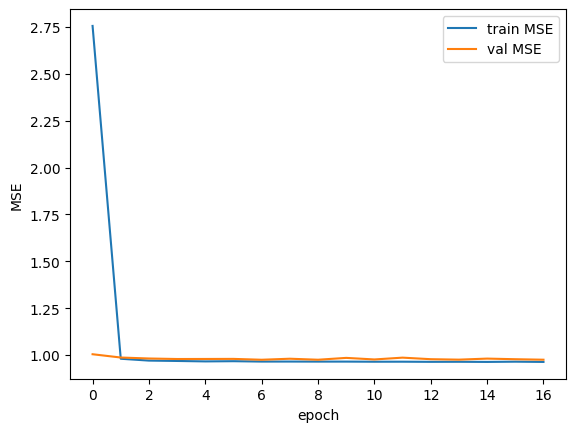

In [ ]:
import matplotlib.pyplot as plt
#y_ticks = np.arange(0, max(ann.history["loss"]), 0.5)
#plt.plot(ann.history["loss"])
#plt.yticks(y_ticks)
#plt.show()

#prints both loss and val_loss.
#NOTE: If lines are close together, it means model is generalizing well since curve isn't deviating from the trained model.
plt.plot(ann2.history['loss'], label='train MSE')
plt.plot(ann2.history['val_loss'], label='val MSE')
plt.legend(); plt.xlabel('epoch'); plt.ylabel('MSE'); plt.show()
#print(max(ann.history["loss"]))

In [6]:
#Testing the data
#loss, accuracy = model.evaluate(x_test,y_test,verbose=1)
y_pred = model.predict(x_test,verbose=0).squeeze()
#print("Predictions: ", y_pred)


y_pred_df = pd.DataFrame({"y prediction": y_pred})
y_test_df = pd.DataFrame({"y test dataset": y_test})
predictions = pd.concat([y_pred_df, y_test_df], axis=1)
print(predictions)
#print(y_test)




       y prediction  y test dataset
0          5.312115             6.6
1          5.352753             4.8
2          5.302525             5.0
3          5.407982             6.1
4          5.367590             6.1
...             ...             ...
19218      5.375243             4.0
19219      6.939044             6.2
19220      5.285410             5.8
19221      5.368737             6.0
19222      5.316179             6.5

[19223 rows x 2 columns]


In [ ]:
#Writing predictions into csv

predictions.to_csv("prediction_continuous.csv", index=False)

pd.DataFrame(ann.history).to_csv("training_hba1c.csv", index=False)

In [ ]:
#from sklearn.linear_model import LinearRegression
#reg = LinearRegression().fit(x_train, y_train)
#print("Baseline R^2 (train):", reg.score(x_train, y_train))
#print("Baseline R^2 (test):", reg.score(x_test, y_test))
